# Disease Classification: Dengue / Chikungunya / Other
### Models: CatBoost · RandomForest · LogisticRegression · HistGradientBoosting

## 1. Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import optuna
from optuna.distributions import FloatDistribution, IntDistribution, CategoricalDistribution

from optuna_integration import OptunaSearchCV
from sklearn.metrics import make_scorer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier, KDTree, NearestCentroid
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, balanced_accuracy_score, roc_auc_score
)
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, PassiveAggressiveClassifier, Perceptron, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier

from catboost import CatBoostClassifier

import torch
import torch.nn as nn

RANDOM_STATE = 42
print('All libraries loaded.')

All libraries loaded.


## 2. Load Data & EDA

In [37]:
recife = pd.read_csv('./recife_fin.csv')
recife.drop(columns=['race', 'hematologic_disease', 'total_symptom_burden', 'Unnamed: 0'], inplace=True)
sinan = pd.read_csv('./sinan_fin.csv')
sinan.drop(columns=['race', 'hematologic_disease', 'total_symptom_burden', 'Unnamed: 0'], inplace=True)
print('Datasets loaded.')

Datasets loaded.


#### Recife

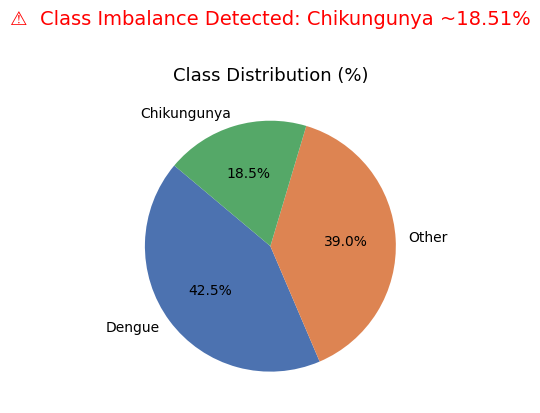

Class counts:
target
Dengue         15738
Other          14413
Chikungunya     6848
Name: count, dtype: int64

Class percentages:
target
Dengue         42.54
Other          38.96
Chikungunya    18.51
Name: count, dtype: float64


In [34]:
# Target distribution
fig, ax = plt.subplots(figsize=(12, 4))

vc_recife = recife['target'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868']
Chik_percent_recife = vc_recife.Chikungunya / (vc_recife.sum())

ax.pie(vc_recife.values, labels=vc_recife.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
ax.set_title('Class Distribution (%)', fontsize=13)

plt.suptitle(f"⚠️  Class Imbalance Detected: Chikungunya ~{(Chik_percent_recife * 100):.2f}%", fontsize=14, color='red', y=1.02)
plt.tight_layout()
plt.show()

print('Class counts:')
print(vc_recife)
print()
print('Class percentages:')
print((vc_recife / vc_recife.sum() * 100).round(2))

#### Sinan

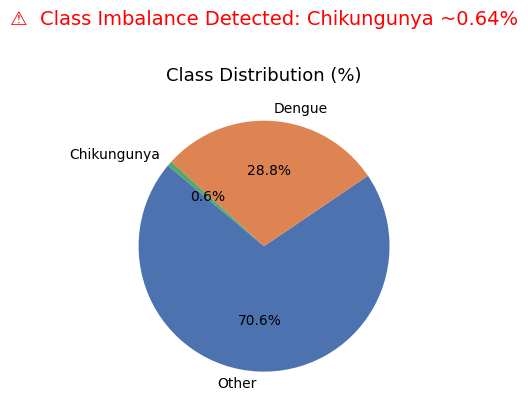

Class counts:
target
Other          27056
Dengue         11024
Chikungunya      247
Name: count, dtype: int64

Class percentages:
target
Other          70.59
Dengue         28.76
Chikungunya     0.64
Name: count, dtype: float64


In [38]:
# Target distribution
fig, ax = plt.subplots(figsize=(12, 4))

vc_sinan = sinan['target'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868']

Chik_percent_sinan = vc_sinan.Chikungunya / (vc_sinan.sum())

ax.pie(vc_sinan.values, labels=vc_sinan.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
ax.set_title('Class Distribution (%)', fontsize=13)

plt.suptitle(f"⚠️  Class Imbalance Detected: Chikungunya ~{(Chik_percent_sinan * 100):.2f}%", fontsize=14, color='red', y=1.02)
plt.tight_layout()
plt.show()

print('Class counts:')
print(vc_sinan)
print()
print('Class percentages:')
print((vc_sinan / vc_sinan.sum() * 100).round(2))

Columns with missing values: 7


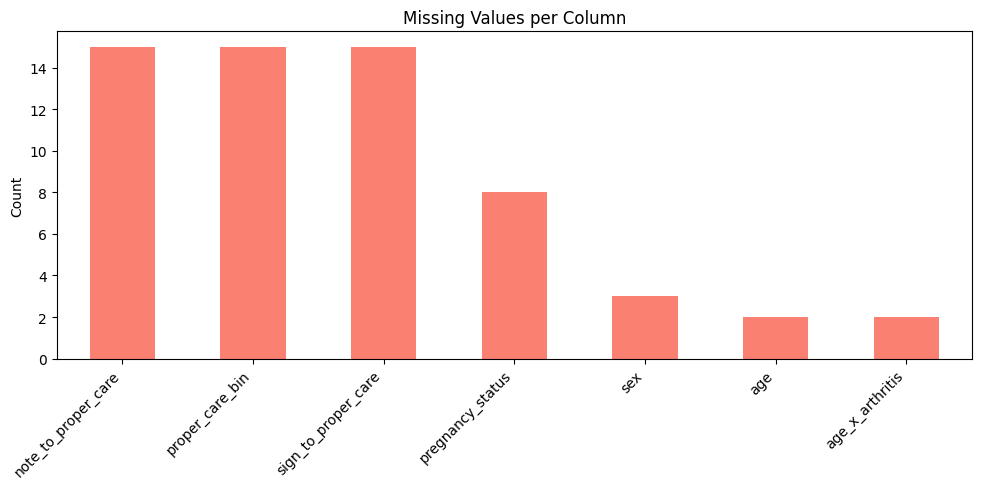

In [4]:
# Missing values heatmap
missing = recife.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Columns with missing values: {len(missing)}')

plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='salmon')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Preprocessing

#### Recife alone

In [5]:
# Drop rows with missing target
recife = recife.dropna(subset=['target']).copy()
print(f'After dropping missing targets: {recife.shape}')

# Separate features and target. target_with_severity is a label-derived column,
# so keeping it in X leaks the answer and makes CV scores meaningless.
X = recife.drop(columns=['target', 'target_with_severity'], errors='ignore')
y = recife['target']

leaky_cols = [c for c in X.columns if any(token in c.lower() for token in ['target', 'severity', 'classi_fin'])]
assert not leaky_cols, f'Leakage columns still present in X: {leaky_cols}'

# Identify column types
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numeric columns ({len(num_cols)}): {len(num_cols)} features')
print('Feature matrix is leakage-safe:', X.shape)

After dropping missing targets: (36999, 57)
Categorical columns (4): ['sex', 'pregnancy_status', 'note_bin', 'proper_care_bin']
Numeric columns (51): 51 features
Feature matrix is leakage-safe: (36999, 55)


In [6]:
# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Classes:', le.classes_)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Classes: ['Chikungunya' 'Dengue' 'Other']
Train size: (29599, 55), Test size: (7400, 55)


In [7]:
# Helper: evaluate and visualize a fitted model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, classes):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    bal_acc = balanced_accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average='macro')

    print('\n' + '=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(f'  Balanced Accuracy : {bal_acc:.4f}')
    print(f'  Macro F1          : {macro_f1:.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=classes))

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nBalanced Acc: {bal_acc:.3f} | Macro F1: {macro_f1:.3f}', fontsize=11)
    plt.tight_layout()
    plt.show()

    return {'model': name, 'balanced_acc': bal_acc, 'macro_f1': macro_f1}

results = []
print('Helper ready.')


Helper ready.


#### Concat

In [50]:
sinan = sinan.dropna(subset=["target"]).copy()
df = pd.concat([sinan, recife], ignore_index=True)
df = df.dropna(subset=['target']).copy()
print(f"After dropping missing targets: {df.shape}")

Xcc = df.drop(columns=['target', 'target_with_severity'], errors='ignore')
ycc = df['target']

After dropping missing targets: (75326, 57)


In [52]:
# Encode target
lecc = LabelEncoder()
ycc_enc = lecc.fit_transform(ycc)
print('Classes:', lecc.classes_)

# Train/test split (stratified)
Xcc_train, Xcc_test, ycc_train, ycc_test = train_test_split(
    Xcc, ycc_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=ycc_enc
)
print(f'Train size: {Xcc_train.shape}, Test size: {Xcc_test.shape}')

Classes: ['Chikungunya' 'Dengue' 'Other']
Train size: (60260, 55), Test size: (15066, 55)


In [55]:
train_df = Xcc_train.copy()
train_df["target"] = ycc_train
counts = train_df["target"].value_counts()
target_n = counts.min() # balance to minority size
balanced_parts = []
for cls, group in train_df.groupby("target"):
    if len(group) > target_n:
        group_down = resample(
            group,
            replace=False,
            n_samples=target_n,
            random_state=RANDOM_STATE
        )
    else:
        group_down = group
    balanced_parts.append(group_down)

train_bal = pd.concat(balanced_parts).sample(frac=1, random_state=RANDOM_STATE)

Xcc_train = train_bal.drop(columns=["target"])
ycc_train = train_bal["target"].to_numpy()

In [61]:
results_cc = []
print("Concat_ready")

Concat_ready


## Model singularity + OptunaSearchCV

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_macro = make_scorer(f1_score, average='macro')

## 4. Model 1 — CatBoost
Handles categoricals natively and supports `class_weights` for imbalance.

#### Recife

[I 2026-05-30 14:13:09,583] A new study created in memory with name: no-name-75e1019b-e6d4-4e4d-9f63-7cb2695966bd


CatBoost class weights: {0: 1.800754395570968, 1: 0.78366428382314, 2: 0.8557097427002024}


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-05-30 14:13:35,496] Trial 0 finished with value: 0.591789823367857 and parameters: {'iterations': 600, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 0.9466503798478175, 'random_strength': 0.004207988669606638, 'border_count': 66}. Best is trial 0 with value: 0.591789823367857.
[I 2026-05-30 14:14:03,287] Trial 1 finished with value: 0.5932546588106002 and parameters: {'iterations': 400, 'learning_rate': 0.19030368381735815, 'depth': 8, 'l2_leaf_reg': 2.1745470981373622, 'random_strength': 0.0012087541473056963, 'border_count': 244}. Best is trial 1 with value: 0.5932546588106002.
[I 2026-05-30 14:14:49,568] Trial 2 finished with value: 0.5673768362335334 and parameters: {'iterations': 900, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 0.040311020093778335, 'random_strength': 0.016480446427978974, 'border_count': 146}. Best is trial 1 with value: 0.5932546588106002.
[I 2026-05-30 14:16:23,077] Trial 3 finished with value: 0.591402363085693 a

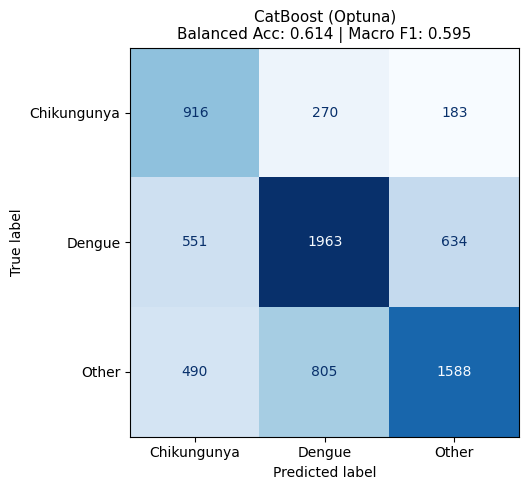

In [24]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
print('CatBoost class weights:', class_weights)

# Impute numerics
for col in num_cols:
    med = X_train_cb[col].median()
    X_train_cb[col] = X_train_cb[col].fillna(med)
    X_test_cb[col] = X_test_cb[col].fillna(med)

# Impute categoricals
for col in cat_cols:
    m = X_train_cb[col].mode(dropna=True)
    mode = m.iloc[0] if not m.empty else 'Missing'
    X_train_cb[col] = X_train_cb[col].fillna(mode).astype(str)
    X_test_cb[col] = X_test_cb[col].fillna(mode).astype(str)

cat_features = cat_cols
cb_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def make_catboost(params):
    return CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='TotalF1',
        random_seed=RANDOM_STATE,
        verbose=0,
        class_weights=class_weights,
        allow_writing_files=False,
        **params
    )

def cb_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 400, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 20.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 250),
    }

    scores = []
    for train_idx, valid_idx in cb_cv.split(X_train_cb, y_train):
        model = make_catboost(params)
        model.fit(
            X_train_cb.iloc[train_idx],
            y_train[train_idx],
            cat_features=cat_features,
            eval_set=(X_train_cb.iloc[valid_idx], y_train[valid_idx]),
            early_stopping_rounds=30,
            verbose=0,
        )
        pred = model.predict(X_train_cb.iloc[valid_idx]).reshape(-1)
        scores.append(f1_score(y_train[valid_idx], pred, average='macro'))
    return float(np.mean(scores))

cb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
cb_study.optimize(cb_objective, n_trials=15, show_progress_bar=True)

print('CatBoost best score:', cb_study.best_value)
print('CatBoost best params:', cb_study.best_params)

catboost_best = make_catboost(cb_study.best_params)
catboost_best.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features,
    verbose=0,
)

y_pred = catboost_best.predict(X_test_cb).reshape(-1)
bal_acc = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print('\n' + '=' * 55)
print('  CatBoost (Optuna)')
print('=' * 55)
print(f'  Balanced Accuracy : {bal_acc:.4f}')
print(f'  Macro F1          : {macro_f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'CatBoost (Optuna)\nBalanced Acc: {bal_acc:.3f} | Macro F1: {macro_f1:.3f}', fontsize=11)
plt.tight_layout()
plt.show()

results.append({'model': 'CatBoost (Optuna)', 'balanced_acc': bal_acc, 'macro_f1': macro_f1})

CatBoost best score: 0.5969340223003107

CatBoost best params: {'iterations': 500, 'learning_rate': 0.08995147228189702, 'depth': 8, 'l2_leaf_reg': 4.2403143657545375, 'random_strength': 0.07495849797769727, 'border_count': 182}

=======================================================
  CatBoost (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.6145
  Macro F1          : 0.5954

              precision    recall  f1-score   support
...
    accuracy                           0.60      7400
   macro avg       0.59      0.61      0.60      7400
weighted avg       0.62      0.60      0.61      7400
```

In [9]:
# Preprocessor for sklearn models (RF, LR, HGB)
# Numeric: median impute
# Categorical: most_frequent impute + label encode (ordinal)
from sklearn.preprocessing import OrdinalEncoder

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

print('Preprocessor ready.')

Preprocessor ready.


#### Concat

[I 2026-05-30 15:47:17,622] A new study created in memory with name: no-name-5cfa66d2-3330-442a-92f0-9e47707e1726


CatBoost class weights: {0: 1.0, 1: 1.0, 2: 1.0}


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-05-30 15:47:47,394] Trial 0 finished with value: 0.6114056755627924 and parameters: {'iterations': 600, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 0.9466503798478175, 'random_strength': 0.004207988669606638, 'border_count': 66}. Best is trial 0 with value: 0.6114056755627924.
[I 2026-05-30 15:48:30,451] Trial 1 finished with value: 0.6194273929050987 and parameters: {'iterations': 400, 'learning_rate': 0.19030368381735815, 'depth': 8, 'l2_leaf_reg': 2.1745470981373622, 'random_strength': 0.0012087541473056963, 'border_count': 244}. Best is trial 1 with value: 0.6194273929050987.
[I 2026-05-30 15:49:30,983] Trial 2 finished with value: 0.6005138846256372 and parameters: {'iterations': 900, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 0.040311020093778335, 'random_strength': 0.016480446427978974, 'border_count': 146}. Best is trial 1 with value: 0.6194273929050987.
[I 2026-05-30 15:50:37,153] Trial 3 finished with value: 0.605477416506293

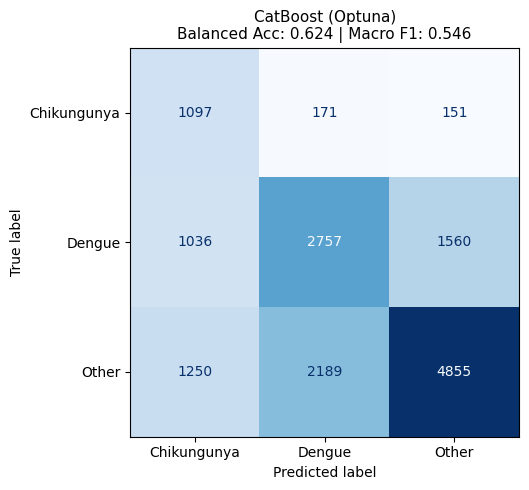

In [57]:
Xcc_train_cb = Xcc_train.copy()
Xcc_test_cb = Xcc_test.copy()

classes = np.unique(ycc_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=ycc_train)
class_weights = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
print('CatBoost class weights:', class_weights)

# Impute numerics
for col in num_cols:
    med = Xcc_train_cb[col].median()
    Xcc_train_cb[col] = Xcc_train_cb[col].fillna(med)
    Xcc_test_cb[col] = Xcc_test_cb[col].fillna(med)

# Impute categoricals
for col in cat_cols:
    m = Xcc_train_cb[col].mode(dropna=True)
    mode = m.iloc[0] if not m.empty else 'Missing'
    Xcc_train_cb[col] = Xcc_train_cb[col].fillna(mode).astype(str)
    Xcc_test_cb[col] = Xcc_test_cb[col].fillna(mode).astype(str)

cat_features = cat_cols
cb_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def make_catboost(params):
    return CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='TotalF1',
        random_seed=RANDOM_STATE,
        verbose=0,
        class_weights=class_weights,
        allow_writing_files=False,
        **params
    )

def cb_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 400, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 20.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 250),
    }

    scores = []
    for train_idx, valid_idx in cb_cv.split(Xcc_train_cb, ycc_train):
        model = make_catboost(params)
        model.fit(
            Xcc_train_cb.iloc[train_idx],
            ycc_train[train_idx],
            cat_features=cat_features,
            eval_set=(Xcc_train_cb.iloc[valid_idx], ycc_train[valid_idx]),
            early_stopping_rounds=30,
            verbose=0,
        )
        pred = model.predict(Xcc_train_cb.iloc[valid_idx]).reshape(-1)
        scores.append(f1_score(ycc_train[valid_idx], pred, average='macro'))
    return float(np.mean(scores))

cb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
cb_study.optimize(cb_objective, n_trials=15, show_progress_bar=True)

print('CatBoost best score:', cb_study.best_value)
print('CatBoost best params:', cb_study.best_params)

catboost_best = make_catboost(cb_study.best_params)
catboost_best.fit(
    Xcc_train_cb,
    ycc_train,
    cat_features=cat_features,
    verbose=0,
)

ycc_pred = catboost_best.predict(Xcc_test_cb).reshape(-1)
bal_acc = balanced_accuracy_score(ycc_test, ycc_pred)
macro_f1 = f1_score(ycc_test, ycc_pred, average='macro')

print('\n' + '=' * 55)
print('  CatBoost (Optuna)')
print('=' * 55)
print(f'  Balanced Accuracy : {bal_acc:.4f}')
print(f'  Macro F1          : {macro_f1:.4f}')
print()
print(classification_report(ycc_test, ycc_pred, target_names=le.classes_))

cm = confusion_matrix(ycc_test, ycc_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'CatBoost (Optuna)\nBalanced Acc: {bal_acc:.3f} | Macro F1: {macro_f1:.3f}', fontsize=11)
plt.tight_layout()
plt.show()

results.append({'model': 'CatBoost (Optuna)', 'balanced_acc': bal_acc, 'macro_f1': macro_f1})

## 5. Model 2 — Random Forest
Uses `class_weight='balanced_subsample'` to address imbalance at each bootstrap.

[I 2026-05-30 14:29:40,394] A new study created in memory with name: no-name-5e7ec509-c7e2-4964-b476-ff627783d41e
[I 2026-05-30 14:29:51,133] Trial 0 finished with value: 0.598086296496917 and parameters: {'classifier__n_estimators': 850, 'classifier__max_depth': 19, 'classifier__min_samples_split': 9, 'classifier__min_samples_leaf': 3, 'classifier__max_features': 'sqrt', 'classifier__class_weight': None, 'classifier__criterion': 'entropy'}. Best is trial 0 with value: 0.598086296496917.
[I 2026-05-30 14:29:59,848] Trial 1 finished with value: 0.5944205493786154 and parameters: {'classifier__n_estimators': 850, 'classifier__max_depth': 15, 'classifier__min_samples_split': 12, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini'}. Best is trial 0 with value: 0.598086296496917.
[I 2026-05-30 14:30:08,437] Trial 2 finished with value: 0.5967520656551565 and parameters: {'classifier__n_estimators': 85

RF best score: 0.599325196323428
RF best params: {'classifier__n_estimators': 950, 'classifier__max_depth': 16, 'classifier__min_samples_split': 16, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__class_weight': 'balanced_subsample', 'classifier__criterion': 'entropy'}

  Random Forest (Optuna)
  Balanced Accuracy : 0.6220
  Macro F1          : 0.6026

              precision    recall  f1-score   support

 Chikungunya       0.47      0.67      0.56      1369
      Dengue       0.65      0.65      0.65      3148
       Other       0.68      0.54      0.60      2883

    accuracy                           0.61      7400
   macro avg       0.60      0.62      0.60      7400
weighted avg       0.63      0.61      0.61      7400



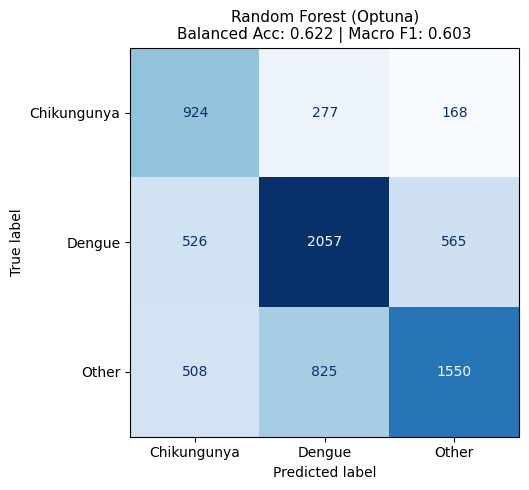

In [ ]:
# RandomForest tuning can become very slow with 10 trials * 5 folds * hundreds of trees.
# Use a lighter RF-specific CV/search budget so this cell finishes reliably in a notebook.
X_train_rf, X_test_rf = X_train.copy(), X_test.copy()
rf_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_param = {
    'classifier__n_estimators': IntDistribution(700, 1000, step=50),
    'classifier__max_depth': IntDistribution(14, 20),
    'classifier__min_samples_split': IntDistribution(9, 16),
    'classifier__min_samples_leaf': IntDistribution(2, 6),
    'classifier__max_features': CategoricalDistribution(['sqrt', 'log2', None]),
    'classifier__class_weight': CategoricalDistribution(['balanced', 'balanced_subsample', None]),
    'classifier__criterion': CategoricalDistribution(['gini', 'entropy'])
}

rf_search = OptunaSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param,
    cv=rf_cv,
    scoring=f1_macro,
    n_trials=10,
    random_state=RANDOM_STATE,
    n_jobs=1,  # RF itself uses all cores; do not parallelize trials/folds too.
    verbose=1,
    refit=True
)

rf_search.fit(X_train, y_train)
print('RF best score:', rf_search.best_score_)
print('RF best params:', rf_search.best_params_)

rf_best = rf_search.best_estimator_

res = evaluate_model(
    'Random Forest (Optuna)',
    rf_best,
    X_train_rf, y_train,
    X_test_rf, y_test,
    le.classes_
)
results.append(res)

#### Eval
RF best score: 0.599325196323428
RF best params: {'classifier__n_estimators': 950, 'classifier__max_depth': 16, 'classifier__min_samples_split': 16, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__class_weight': 'balanced_subsample', 'classifier__criterion': 'entropy'}

=======================================================
  Random Forest (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.6220
  Macro F1          : 0.6026

              precision    recall  f1-score   support

 Chikungunya       0.47      0.67      0.56      1369
      Dengue       0.65      0.65      0.65      3148
       Other       0.68      0.54      0.60      2883

    accuracy                           0.61      7400
   macro avg       0.60      0.62      0.60      7400
weighted avg       0.63      0.61      0.61      7400
```

#### Concat

[I 2026-05-30 16:18:45,183] A new study created in memory with name: no-name-92cc863e-a219-4e18-9e8a-376e9cd43f91
[I 2026-05-30 16:18:54,905] Trial 0 finished with value: 0.6143657934420451 and parameters: {'classifier__n_estimators': 600, 'classifier__max_depth': 19, 'classifier__min_samples_split': 9, 'classifier__min_samples_leaf': 3, 'classifier__max_features': 'sqrt', 'classifier__class_weight': None, 'classifier__criterion': 'entropy'}. Best is trial 0 with value: 0.6143657934420451.
[I 2026-05-30 16:19:04,644] Trial 1 finished with value: 0.6125869603815534 and parameters: {'classifier__n_estimators': 600, 'classifier__max_depth': 15, 'classifier__min_samples_split': 12, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini'}. Best is trial 0 with value: 0.6143657934420451.
[I 2026-05-30 16:19:14,482] Trial 2 finished with value: 0.611725594681765 and parameters: {'classifier__n_estimators': 

RF best score: 0.6144948787368927
RF best params: {'classifier__n_estimators': 300, 'classifier__max_depth': 18, 'classifier__min_samples_split': 15, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'sqrt', 'classifier__class_weight': None, 'classifier__criterion': 'gini'}

  Random Forest (Optuna)
  Balanced Accuracy : 0.6250
  Macro F1          : 0.5399

              precision    recall  f1-score   support

 Chikungunya       0.32      0.80      0.45      1419
      Dengue       0.54      0.49      0.52      5353
       Other       0.74      0.58      0.65      8294

    accuracy                           0.57     15066
   macro avg       0.53      0.62      0.54     15066
weighted avg       0.63      0.57      0.58     15066



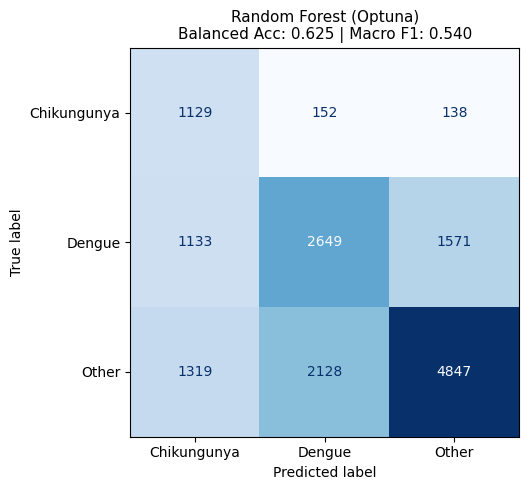

In [58]:
# RandomForest tuning can become very slow with 10 trials * 5 folds * hundreds of trees.
# Use a lighter RF-specific CV/search budget so this cell finishes reliably in a notebook.
Xcc_train_rf, Xcc_test_rf = Xcc_train.copy(), Xcc_test.copy()
rf_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

ccrf_param = {
    'classifier__n_estimators': IntDistribution(200, 1000, step=100),
    'classifier__max_depth': IntDistribution(14, 20),
    'classifier__min_samples_split': IntDistribution(9, 16),
    'classifier__min_samples_leaf': IntDistribution(2, 6),
    'classifier__max_features': CategoricalDistribution(['sqrt', 'log2', None]),
    'classifier__class_weight': CategoricalDistribution(['balanced', 'balanced_subsample', None]),
    'classifier__criterion': CategoricalDistribution(['gini', 'entropy'])
}

ccrf_search = OptunaSearchCV(
    estimator=rf_pipeline,
    param_distributions=ccrf_param,
    cv=rf_cv,
    scoring=f1_macro,
    n_trials=20,
    random_state=RANDOM_STATE,
    n_jobs=1,  # RF itself uses all cores; do not parallelize trials/folds too.
    verbose=1,
    refit=True
)

ccrf_search.fit(Xcc_train, ycc_train)
print('RF best score:', ccrf_search.best_score_)
print('RF best params:', ccrf_search.best_params_)

rf_best = ccrf_search.best_estimator_

res = evaluate_model(
    'Random Forest (Optuna)',
    rf_best,
    Xcc_train_rf, ycc_train,
    Xcc_test_rf, ycc_test,
    le.classes_
)
results.append(res)

## Model 3 - Linear models

### Logistic Regression

#### Recife

[I 2026-05-30 13:37:16,295] A new study created in memory with name: no-name-5cff69a5-4e7c-4d3d-9f4f-2a1c8a62e395


LR Train: (29576, 55)  |  LR Test: (7395, 55)


[I 2026-05-30 13:37:21,103] Trial 4 finished with value: 0.5421220398406653 and parameters: {'classifier__C': 0.009748249261685372, 'classifier__fit_intercept': True, 'classifier__class_weight': None, 'classifier__tol': 0.009108059499677594, 'classifier__l1_ratio': 0}. Best is trial 4 with value: 0.5421220398406653.
[I 2026-05-30 13:37:24,663] Trial 0 finished with value: 0.5216046787681945 and parameters: {'classifier__C': 0.006923080243098929, 'classifier__fit_intercept': False, 'classifier__class_weight': 'balanced', 'classifier__tol': 0.006242719864597822, 'classifier__l1_ratio': 0.5}. Best is trial 4 with value: 0.5421220398406653.
[I 2026-05-30 13:37:25,194] Trial 16 finished with value: 0.49084868098082224 and parameters: {'classifier__C': 0.0011178694845297222, 'classifier__fit_intercept': False, 'classifier__class_weight': None, 'classifier__tol': 0.0008300405140930193, 'classifier__l1_ratio': 0.5}. Best is trial 4 with value: 0.5421220398406653.
[I 2026-05-30 13:37:26,577] Tr

LR best score: 0.543062024395781
LR best params: {'classifier__C': 7.6818575520771155, 'classifier__fit_intercept': True, 'classifier__class_weight': None, 'classifier__tol': 0.00021487847249799646, 'classifier__l1_ratio': 0.5}

  Logistic Regression (Optuna)
  Balanced Accuracy : 0.5397
  Macro F1          : 0.5431

              precision    recall  f1-score   support

 Chikungunya       0.50      0.45      0.48      1370
      Dengue       0.55      0.67      0.60      3147
       Other       0.60      0.50      0.55      2878

    accuracy                           0.56      7395
   macro avg       0.55      0.54      0.54      7395
weighted avg       0.56      0.56      0.56      7395



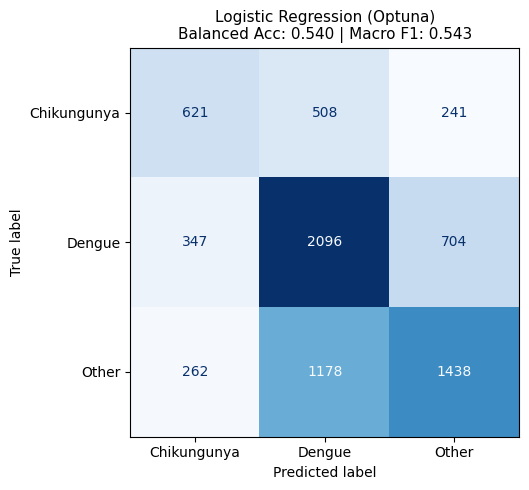

In [ ]:
# --- Drop ALL rows that contain any missing value ---
recife_lr = recife.dropna()
X_lr = recife_lr.drop(columns=['target', 'target_with_severity'], errors='ignore')
y_lr = le.transform(recife_lr['target'])   # reuse fitted LabelEncoder

# Stratified split on the clean subset
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=RANDOM_STATE, stratify=y_lr
)
print(f'LR Train: {X_train_lr.shape}  |  LR Test: {X_test_lr.shape}')

# Preprocessor with NO imputer (data is already clean)
from sklearn.preprocessing import OrdinalEncoder

lr_cat_cols = X_lr.select_dtypes(include=['object', 'string']).columns.tolist()
lr_num_cols = X_lr.select_dtypes(include=['number']).columns.tolist()

lr_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), lr_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), lr_cat_cols)
])

lr_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
        solver="saga",
    ))
])

lr_param = {
    "classifier__C": FloatDistribution(1e-3, 20.0, log=True),
    # "classifier__solver": CategoricalDistribution(["lbfgs", "liblinear", "saga"]),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__class_weight": CategoricalDistribution([None, "balanced"]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__l1_ratio": CategoricalDistribution([0, 0.5, 1]),
}

lr_search = OptunaSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

lr_search.fit(X_train_lr, y_train_lr)

print("LR best score:", lr_search.best_score_)
print("LR best params:", lr_search.best_params_)

lr_best = lr_search.best_estimator_

res = evaluate_model(
    "Logistic Regression (Optuna)",
    lr_best,
    X_train_lr, y_train_lr,
    X_test_lr, y_test_lr,
    le.classes_
)
results_cc.append(res)

LR best score: 0.543062024395781

LR best params: {'classifier__C': 7.6818575520771155, 'classifier__fit_intercept': True, 'classifier__class_weight': None, 'classifier__tol': 0.00021487847249799646, 'classifier__l1_ratio': 0.5}

=======================================================
  Logistic Regression (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5397
  Macro F1          : 0.5431

              precision    recall  f1-score   support

 Chikungunya       0.50      0.45      0.48      1370
      Dengue       0.55      0.67      0.60      3147
       Other       0.60      0.50      0.55      2878

    accuracy                           0.56      7395
   macro avg       0.55      0.54      0.54      7395
weighted avg       0.56      0.56      0.56      7395
```

#### Concat

[I 2026-05-30 17:57:58,072] A new study created in memory with name: no-name-ef108eb0-2ebd-4266-b7e2-86b72e467e38


LR Train: (15664, 55)  |  LR Test: (13477, 55)


[I 2026-05-30 17:58:00,490] Trial 11 finished with value: 0.5711147477607688 and parameters: {'classifier__C': 0.0015610115447875692, 'classifier__fit_intercept': True, 'classifier__class_weight': 'balanced', 'classifier__tol': 0.00813622280362591, 'classifier__l1_ratio': 0}. Best is trial 11 with value: 0.5711147477607688.
[I 2026-05-30 17:58:01,011] Trial 14 finished with value: 0.5725224576511547 and parameters: {'classifier__C': 0.00589522478667128, 'classifier__fit_intercept': False, 'classifier__class_weight': 'balanced', 'classifier__tol': 0.0054965031416587895, 'classifier__l1_ratio': 0}. Best is trial 14 with value: 0.5725224576511547.
[I 2026-05-30 17:58:01,477] Trial 3 finished with value: 0.5729149095631061 and parameters: {'classifier__C': 0.546375551325559, 'classifier__fit_intercept': True, 'classifier__class_weight': 'balanced', 'classifier__tol': 0.008876956650681457, 'classifier__l1_ratio': 0.5}. Best is trial 3 with value: 0.5729149095631061.
[I 2026-05-30 17:58:02,3

LR best score: 0.5748244938202639
LR best params: {'classifier__C': 2.0049897374260213, 'classifier__fit_intercept': True, 'classifier__class_weight': 'balanced', 'classifier__tol': 0.002918142175675396, 'classifier__l1_ratio': 0}

  LR (saga) (Optuna)
  Balanced Accuracy : 0.5798
  Macro F1          : 0.5015

              precision    recall  f1-score   support

 Chikungunya       0.30      0.76      0.43      1419
      Dengue       0.49      0.40      0.44      4709
       Other       0.70      0.58      0.63      7349

    accuracy                           0.53     13477
   macro avg       0.50      0.58      0.50     13477
weighted avg       0.59      0.53      0.54     13477



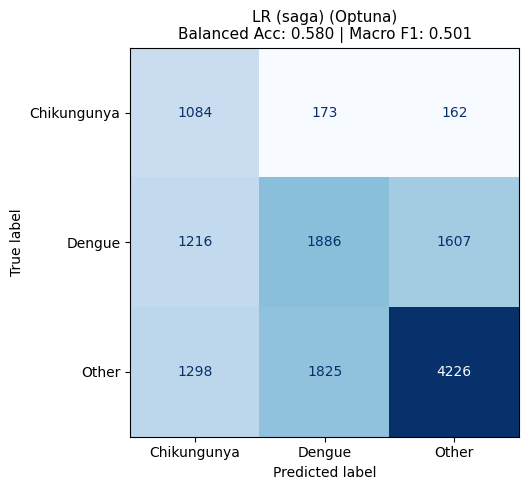

In [68]:
# --- Drop ALL rows that contain any missing value ---

# Stratified split on the clean subset
cc_train2 = Xcc_train.copy()
cc_train2["target"] = ycc_train
cc_test2 = Xcc_test.copy()
cc_test2["target"] = ycc_test
cc_train2.dropna(inplace=True)
cc_test2.dropna(inplace=True)
Xcc_lr = pd.concat([cc_train2, cc_test2], ignore_index=True).drop(columns=["target"])

Xcc_train_lr, Xcc_test_lr, ycc_train_lr, ycc_test_lr = cc_train2.drop(columns=["target"]), cc_test2.drop(columns=["target"]), cc_train2["target"], cc_test2["target"]
print(f'LR Train: {Xcc_train_lr.shape}  |  LR Test: {Xcc_test_lr.shape}')

lr_cat_cols = Xcc_lr.select_dtypes(include=['object', 'string']).columns.tolist()
lr_num_cols = Xcc_lr.select_dtypes(include=['number']).columns.tolist()

cc_lr_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), lr_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), lr_cat_cols)
])

cclr_pipeline = Pipeline([
    ('preprocessor', cc_lr_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=4000,
        random_state=RANDOM_STATE,
        solver="saga",
    ))
])

cclr_param = {
    "classifier__C": FloatDistribution(1e-3, 20.0, log=True),
    # "classifier__solver": CategoricalDistribution(["lbfgs", "liblinear", "saga"]),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__class_weight": CategoricalDistribution([None, "balanced"]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__l1_ratio": CategoricalDistribution([0, 0.5, 1]),
}

cclr_search = OptunaSearchCV(
    estimator=cclr_pipeline,
    param_distributions=cclr_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

cclr_search.fit(Xcc_train_lr, ycc_train_lr)

print("LR best score:", cclr_search.best_score_)
print("LR best params:", cclr_search.best_params_)

cclr_best = cclr_search.best_estimator_

ccres_lr = evaluate_model(
    "LR (saga) (Optuna)",
    cclr_best,
    Xcc_train_lr, ycc_train_lr,
    Xcc_test_lr, ycc_test_lr,
    le.classes_
)
results_cc.append(ccres_lr)

#####
LR best score: 0.5741930268233292

LR best params: {'classifier__C': 0.02768462232213521, 'classifier__fit_intercept': True, 'classifier__class_weight': 'balanced', 'classifier__tol': 0.0023385519489361748, 'classifier__l1_ratio': 0}

=======================================================
  Logistic Regression (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5795
  Macro F1          : 0.5010

              precision    recall  f1-score   support

 Chikungunya       0.30      0.76      0.43      1419
      Dengue       0.48      0.40      0.44      4709
       Other       0.70      0.57      0.63      7349

    accuracy                           0.53     13477
   macro avg       0.50      0.58      0.50     13477
weighted avg       0.59      0.53      0.54     13477
```

##### Solver = liblinear

[I 2026-05-30 17:35:37,873] A new study created in memory with name: no-name-b7bd1695-70b4-4fd5-8c74-4e97f767a883
[I 2026-05-30 17:35:42,205] Trial 5 finished with value: 0.57033627670024 and parameters: {'classifier__estimator__C': 0.001077354723665384, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__tol': 0.00020041616880893347, 'classifier__estimator__intercept_scaling': 0.22140368443554392}. Best is trial 5 with value: 0.57033627670024.
[I 2026-05-30 17:35:44,898] Trial 0 finished with value: 0.5680544088285334 and parameters: {'classifier__estimator__C': 0.0029496777711389395, 'classifier__estimator__class_weight': None, 'classifier__estimator__tol': 0.00013206816675982857, 'classifier__estimator__intercept_scaling': 2.5207264959225304}. Best is trial 5 with value: 0.57033627670024.
[I 2026-05-30 17:36:05,955] Trial 17 finished with value: 0.5702572090347554 and parameters: {'classifier__estimator__C': 0.014911513718680741, 'classifier__estimator__class_

LR best score: 0.5729421016786796
LR best params: {'classifier__estimator__C': 0.3602561299074157, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__tol': 0.002509730441389294, 'classifier__estimator__intercept_scaling': 0.26585993375925215}

  LR (liblinear) (Optuna)
  Balanced Accuracy : 0.5772
  Macro F1          : 0.4948

              precision    recall  f1-score   support

 Chikungunya       0.29      0.78      0.42      1419
      Dengue       0.48      0.38      0.42      4709
       Other       0.70      0.58      0.64      7349

    accuracy                           0.53     13477
   macro avg       0.49      0.58      0.49     13477
weighted avg       0.58      0.53      0.54     13477



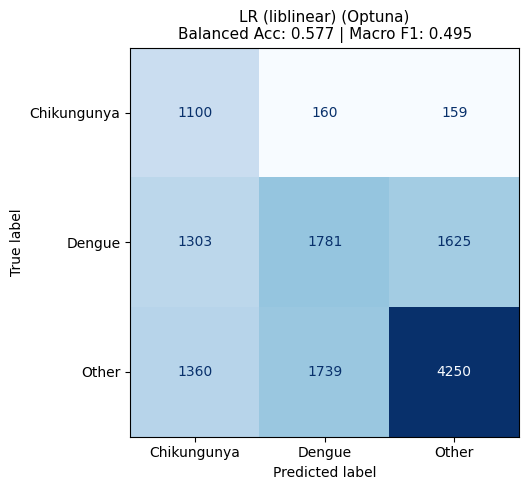

In [67]:
cc_lr_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), lr_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), lr_cat_cols)
])

cclr_pipeline2 = Pipeline([
    ('preprocessor', cc_lr_preprocessor),
    ('classifier', OneVsRestClassifier(
        LogisticRegression(
            max_iter=4000,
            random_state=RANDOM_STATE,
            solver="liblinear",
            l1_ratio=0,
            dual=True,
            fit_intercept=True
        )
    ))
])

cclr_param2 = {
    "classifier__estimator__C": FloatDistribution(1e-3, 20.0, log=True),
    # "classifier__solver": CategoricalDistribution(["lbfgs", "liblinear", "saga"]),
    # "classifier__estimator__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__estimator__class_weight": CategoricalDistribution([None, "balanced"]),
    "classifier__estimator__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__estimator__intercept_scaling": FloatDistribution(0.1, 10.0, log=True),
}

cclr_search2 = OptunaSearchCV(
    estimator=cclr_pipeline2,
    param_distributions=cclr_param2,
    cv=cv,
    scoring="f1_macro",
    n_trials=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

cclr_search2.fit(Xcc_train_lr, ycc_train_lr)

print("LR best score:", cclr_search2.best_score_)
print("LR best params:", cclr_search2.best_params_)

cclr_best2 = cclr_search2.best_estimator_

ccres_lr2 = evaluate_model(
    "LR (liblinear) (Optuna)",
    cclr_best2,
    Xcc_train_lr, ycc_train_lr,
    Xcc_test_lr, ycc_test_lr,
    le.classes_
)
results_cc.append(ccres_lr2)

### RidgeClassifier

#### Recife

[I 2026-05-30 13:41:25,113] A new study created in memory with name: no-name-2d7d686c-8050-4473-b0b2-04e1654cd1ed


RC Train: (29576, 55)  |  RC Test: (7395, 55)


[I 2026-05-30 13:41:29,323] Trial 0 finished with value: 0.5323855504546633 and parameters: {'classifier__alpha': 10.9577141439517, 'classifier__fit_intercept': False, 'classifier__tol': 0.0029419781113088185}. Best is trial 0 with value: 0.5323855504546633.
[I 2026-05-30 13:41:29,469] Trial 7 finished with value: 0.5324456285750607 and parameters: {'classifier__alpha': 10.598714067157365, 'classifier__fit_intercept': False, 'classifier__tol': 0.00012848758949128005}. Best is trial 7 with value: 0.5324456285750607.
[I 2026-05-30 13:41:29,492] Trial 10 finished with value: 0.5321755771265173 and parameters: {'classifier__alpha': 12.609771365126374, 'classifier__fit_intercept': False, 'classifier__tol': 0.008579324257436863}. Best is trial 7 with value: 0.5324456285750607.
[I 2026-05-30 13:41:29,613] Trial 6 finished with value: 0.5324469135200496 and parameters: {'classifier__alpha': 11.004239652831364, 'classifier__fit_intercept': False, 'classifier__tol': 0.00025640694253432504}. Best

Ridge best score: 0.5324469135200496
Ridge best params: {'classifier__alpha': 11.004239652831364, 'classifier__fit_intercept': False, 'classifier__tol': 0.00025640694253432504}

  Ridge Classifier (Optuna)
  Balanced Accuracy : 0.5238
  Macro F1          : 0.5299

              precision    recall  f1-score   support

 Chikungunya       0.51      0.38      0.43      1370
      Dengue       0.54      0.71      0.62      3147
       Other       0.61      0.48      0.54      2878

    accuracy                           0.56      7395
   macro avg       0.55      0.52      0.53      7395
weighted avg       0.56      0.56      0.55      7395



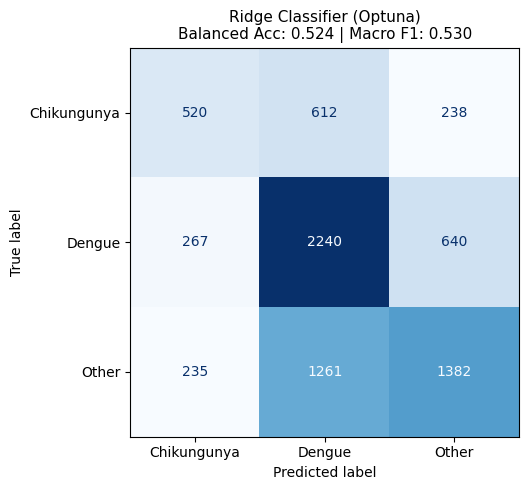

In [ ]:
recife_rc = recife.dropna()
X_rc = recife_rc.drop(columns=['target', 'target_with_severity'], errors='ignore')
y_rc = le.transform(recife_rc['target'])   # reuse fitted LabelEncoder

# Stratified split on the clean subset
X_train_rc, X_test_rc, y_train_rc, y_test_rc = train_test_split(
    X_rc, y_rc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_rc
)
print(f'RC Train: {X_train_rc.shape}  |  RC Test: {X_test_rc.shape}')

rc_cat_cols = X_rc.select_dtypes(include=['object', 'string']).columns.tolist()
rc_num_cols = X_rc.select_dtypes(include=['number']).columns.tolist()

rc_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), rc_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), rc_cat_cols)
])

rc_pipeline = Pipeline([
    ('preprocessor', rc_preprocessor),
    ('classifier', RidgeClassifier(
        max_iter=4000,
        random_state=RANDOM_STATE,
        solver="cholesky",
        class_weight=None,
    ))
])

rc_param = {
    "classifier__alpha": FloatDistribution(10, 18.0, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
}

rc_search = OptunaSearchCV(
    estimator=rc_pipeline,
    param_distributions=rc_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

rc_search.fit(X_train_rc, y_train_rc)

print("Ridge best score:", rc_search.best_score_)
print("Ridge best params:", rc_search.best_params_)

rc_best = rc_search.best_estimator_

res_rc = evaluate_model(
    "Ridge Classifier (Optuna)",
    rc_best,
    X_train_rc, y_train_rc,
    X_test_rc, y_test_rc,
    le.classes_
)
results.append(res_rc)

##### Solver: cholesky
Ridge best score: 0.5324469135200496

Ridge best params: {'classifier__alpha': 11.004239652831364, 'classifier__fit_intercept': False, 'classifier__tol': 0.00025640694253432504}

=======================================================
  Ridge Classifier (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5238
  Macro F1          : 0.5299

              precision    recall  f1-score   support

 Chikungunya       0.51      0.38      0.43      1370
      Dengue       0.54      0.71      0.62      3147
       Other       0.61      0.48      0.54      2878

    accuracy                           0.56      7395
   macro avg       0.55      0.52      0.53      7395
weighted avg       0.56      0.56      0.55      7395
```

##### Solver: saga
RRidge best score: 0.5322398523266554

Ridge best params: {'classifier__alpha': 12.621782384721437, 'classifier__fit_intercept': False, 'classifier__tol': 0.0014656421322513037}

=======================================================
  Ridge Classifier (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5230
  Macro F1          : 0.5291

              precision    recall  f1-score   support

 Chikungunya       0.51      0.38      0.43      1370
      Dengue       0.54      0.71      0.62      3147
       Other       0.61      0.48      0.54      2878

    accuracy                           0.56      7395
   macro avg       0.55      0.52      0.53      7395
weighted avg       0.56      0.56      0.55      7395
```

#### Concat

[I 2026-05-30 19:01:20,571] A new study created in memory with name: no-name-87437872-2473-4e10-8b39-e08fb32aa173


RC Train: (15664, 55)  |  RC Test: (13477, 55)


[I 2026-05-30 19:01:24,372] Trial 5 finished with value: 0.563473247875777 and parameters: {'classifier__alpha': 5.668027837569352, 'classifier__fit_intercept': True, 'classifier__tol': 0.008745828062898819}. Best is trial 5 with value: 0.563473247875777.
[I 2026-05-30 19:01:24,531] Trial 1 finished with value: 0.5641915251653156 and parameters: {'classifier__alpha': 8.670036258270077, 'classifier__fit_intercept': False, 'classifier__tol': 0.008935328595888168}. Best is trial 1 with value: 0.5641915251653156.
[I 2026-05-30 19:01:25,212] Trial 3 finished with value: 0.5643777663214047 and parameters: {'classifier__alpha': 2.2341575145797843, 'classifier__fit_intercept': False, 'classifier__tol': 0.008105283016272884}. Best is trial 3 with value: 0.5643777663214047.
[I 2026-05-30 19:01:30,574] Trial 4 finished with value: 0.5650084960109674 and parameters: {'classifier__alpha': 1.2711225999310471, 'classifier__fit_intercept': False, 'classifier__tol': 0.0055950100311189105}. Best is tria

RC best score: 0.5663479405116133
RC best params: {'classifier__alpha': 0.3965723353830046, 'classifier__fit_intercept': True, 'classifier__tol': 0.0010826404647333444}

  RC (saga) (Optuna)
  Balanced Accuracy : 0.5731
  Macro F1          : 0.4812

              precision    recall  f1-score   support

 Chikungunya       0.28      0.80      0.41      1419
      Dengue       0.49      0.32      0.39      4709
       Other       0.70      0.60      0.64      7349

    accuracy                           0.52     13477
   macro avg       0.49      0.57      0.48     13477
weighted avg       0.58      0.52      0.53     13477



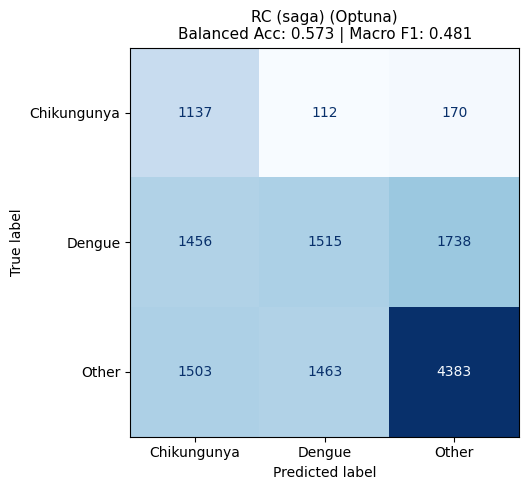

In [74]:
# --- Drop ALL rows that contain any missing value ---

Xcc_rc = pd.concat([cc_train2, cc_test2], ignore_index=True).drop(columns=["target"])

Xcc_train_rc, Xcc_test_rc, ycc_train_rc, ycc_test_rc = cc_train2.drop(columns=["target"]), cc_test2.drop(columns=["target"]), cc_train2["target"], cc_test2["target"]
print(f'RC Train: {Xcc_train_rc.shape}  |  RC Test: {Xcc_test_rc.shape}')

rc_cat_cols = Xcc_rc.select_dtypes(include=['object', 'string']).columns.tolist()
rc_num_cols = Xcc_rc.select_dtypes(include=['number']).columns.tolist()

cc_rc_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), rc_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), rc_cat_cols)
])

ccrc_pipeline = Pipeline([
    ('preprocessor', cc_rc_preprocessor),
    ('classifier', RidgeClassifier(
        max_iter=4000,
        random_state=RANDOM_STATE,
        solver="saga",
    ))
])

ccrc_param = {
    "classifier__alpha": FloatDistribution(1e-2, 20.0, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
}

ccrc_search = OptunaSearchCV(
    estimator=ccrc_pipeline,
    param_distributions=ccrc_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

ccrc_search.fit(Xcc_train_rc, ycc_train_rc)

print("RC best score:", ccrc_search.best_score_)
print("RC best params:", ccrc_search.best_params_)

ccrc_best = ccrc_search.best_estimator_

ccres_rc = evaluate_model(
    "RC (saga) (Optuna)",
    ccrc_best,
    Xcc_train_rc, ycc_train_rc,
    Xcc_test_rc, ycc_test_rc,
    le.classes_
)
results_cc.append(ccres_rc)

### SGDClassifier

#### Recife

[I 2026-05-30 13:42:15,543] A new study created in memory with name: no-name-a0faf371-fe4c-4550-bc11-5807c0ae5218


SGDC Train: (29576, 55)  |  SGDC Test: (7395, 55)


[I 2026-05-30 13:42:18,358] Trial 5 finished with value: 0.4080217271252319 and parameters: {'classifier__loss': 'squared_hinge', 'classifier__penalty': 'l2', 'classifier__alpha': 0.001434204850169964, 'classifier__fit_intercept': True, 'classifier__tol': 0.0052197958854765395, 'classifier__epsilon': 0.34067252125468317, 'classifier__learning_rate': 'invscaling', 'classifier__power_t': 0.04209747007550774, 'classifier__eta0': 1.6183976106106328, 'classifier__class_weight': None}. Best is trial 5 with value: 0.4080217271252319.
[I 2026-05-30 13:42:18,750] Trial 0 finished with value: 0.4072288401605035 and parameters: {'classifier__loss': 'perceptron', 'classifier__penalty': 'l2', 'classifier__alpha': 0.0025898457589184827, 'classifier__fit_intercept': True, 'classifier__tol': 0.00011350107954317212, 'classifier__epsilon': 0.005240553062065869, 'classifier__learning_rate': 'invscaling', 'classifier__power_t': 0.026161200541476866, 'classifier__eta0': 0.1499911073778672, 'classifier__cla

SGD best score: 0.5354872872987052
SGD best params: {'classifier__loss': 'squared_hinge', 'classifier__penalty': 'l2', 'classifier__alpha': 0.0009645767585516975, 'classifier__fit_intercept': True, 'classifier__tol': 0.0003202481317848167, 'classifier__epsilon': 0.005772075282658919, 'classifier__learning_rate': 'adaptive', 'classifier__power_t': 0.018171585254386568, 'classifier__eta0': 0.015908567782468682, 'classifier__class_weight': None}

  SGD Classifier (Optuna)
  Balanced Accuracy : 0.5268
  Macro F1          : 0.5333

              precision    recall  f1-score   support

 Chikungunya       0.51      0.39      0.45      1370
      Dengue       0.55      0.70      0.61      3147
       Other       0.61      0.49      0.54      2878

    accuracy                           0.56      7395
   macro avg       0.56      0.53      0.53      7395
weighted avg       0.56      0.56      0.55      7395



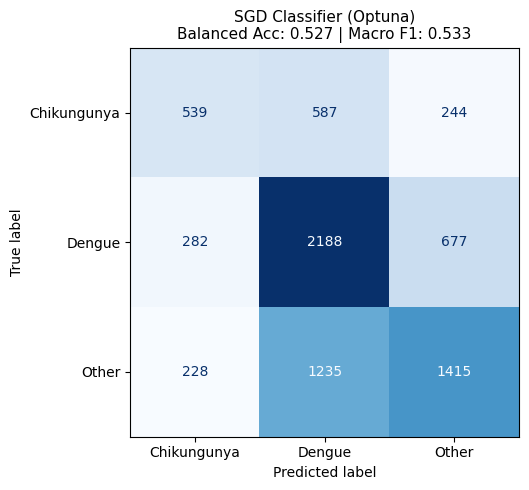

In [ ]:
recife_sgdc = recife.dropna()
X_sgdc = recife_sgdc.drop(columns=['target', 'target_with_severity'], errors='ignore')
y_sgdc = le.transform(recife_sgdc['target'])   # reuse fitted LabelEncoder

# Stratified split on the clean subset
X_train_sgdc, X_test_sgdc, y_train_sgdc, y_test_sgdc = train_test_split(
    X_sgdc, y_sgdc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_sgdc
)
print(f'SGDC Train: {X_train_sgdc.shape}  |  SGDC Test: {X_test_sgdc.shape}')

sgdc_cat_cols = X_sgdc.select_dtypes(include=['object', 'string']).columns.tolist()
sgdc_num_cols = X_sgdc.select_dtypes(include=['number']).columns.tolist()

sgdc_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), sgdc_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), sgdc_cat_cols)
])

sgdc_pipeline = Pipeline([
    ('preprocessor', sgdc_preprocessor),
    ('classifier', SGDClassifier(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ))
])

sgdc_param = {
    "classifier__loss": CategoricalDistribution(['hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive']),
    "classifier__penalty": CategoricalDistribution(['l2', 'l1', 'elasticnet']),
    "classifier__alpha": FloatDistribution(1e-5, 20, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__epsilon": FloatDistribution(1e-3, 1, log=True),
    "classifier__learning_rate": CategoricalDistribution(['constant', 'optimal', 'invscaling', 'adaptive']),
    "classifier__power_t": FloatDistribution(1e-2, 1.5, log=True),
    "classifier__eta0": FloatDistribution(1e-3, 2, log=True),
    "classifier__class_weight": CategoricalDistribution(['balanced', None]),
}

sgdc_search = OptunaSearchCV(
    estimator=sgdc_pipeline,
    param_distributions=sgdc_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

sgdc_search.fit(X_train_sgdc, y_train_sgdc)

print("SGD best score:", sgdc_search.best_score_)
print("SGD best params:", sgdc_search.best_params_)

sgdc_best = sgdc_search.best_estimator_

res_sgdc = evaluate_model(
    "SGD Classifier (Optuna)",
    sgdc_best,
    X_train_sgdc, y_train_sgdc,
    X_test_sgdc, y_test_sgdc,
    le.classes_
)
results.append(res_sgdc)

SGD best score: 0.5354872872987052

SGD best params: {'classifier__loss': 'squared_hinge', 'classifier__penalty': 'l2', 'classifier__alpha': 0.0009645767585516975, 'classifier__fit_intercept': True, 'classifier__tol': 0.0003202481317848167, 'classifier__epsilon': 0.005772075282658919, 'classifier__learning_rate': 'adaptive', 'classifier__power_t': 0.018171585254386568, 'classifier__eta0': 0.015908567782468682, 'classifier__class_weight': None}

=======================================================
  SGD Classifier (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5268
  Macro F1          : 0.5333

              precision    recall  f1-score   support

 Chikungunya       0.51      0.39      0.45      1370
      Dengue       0.55      0.70      0.61      3147
       Other       0.61      0.49      0.54      2878

    accuracy                           0.56      7395
   macro avg       0.56      0.53      0.53      7395
weighted avg       0.56      0.56      0.55      7395
```

#### Concat

[I 2026-05-30 18:50:12,493] A new study created in memory with name: no-name-7caa6cfc-9abd-4a16-97c4-987afd192b2e


SGD Classifier Train: (15664, 55)  |  SGD Classifier Test: (13477, 55)


[I 2026-05-30 18:50:14,081] Trial 2 finished with value: 0.3115044773940539 and parameters: {'classifier__loss': 'squared_epsilon_insensitive', 'classifier__penalty': 'l2', 'classifier__alpha': 0.011738452401140936, 'classifier__fit_intercept': True, 'classifier__tol': 0.002845685983907392, 'classifier__epsilon': 0.004553504525963773, 'classifier__learning_rate': 'invscaling', 'classifier__power_t': 0.07140869329834594, 'classifier__eta0': 0.051982021831945134, 'classifier__class_weight': 'balanced'}. Best is trial 2 with value: 0.3115044773940539.
[I 2026-05-30 18:50:14,221] Trial 0 finished with value: 0.525810589727401 and parameters: {'classifier__loss': 'epsilon_insensitive', 'classifier__penalty': 'elasticnet', 'classifier__alpha': 0.01828803378158867, 'classifier__fit_intercept': False, 'classifier__tol': 0.005345029237147446, 'classifier__epsilon': 0.9440866257540076, 'classifier__learning_rate': 'optimal', 'classifier__power_t': 0.13595049810873208, 'classifier__eta0': 0.03529

SGD Classifier best score: 0.5699018707998098
SGD Classifier best params: {'classifier__loss': 'log_loss', 'classifier__penalty': 'l2', 'classifier__alpha': 1.7602882315959455e-05, 'classifier__fit_intercept': False, 'classifier__tol': 0.0019681365802091716, 'classifier__epsilon': 0.0015046551015638688, 'classifier__learning_rate': 'adaptive', 'classifier__power_t': 0.3822288427552992, 'classifier__eta0': 0.009761115309346292, 'classifier__class_weight': None}

  SGD Classifier (Optuna)
  Balanced Accuracy : 0.5760
  Macro F1          : 0.4891

              precision    recall  f1-score   support

 Chikungunya       0.29      0.79      0.42      1419
      Dengue       0.48      0.36      0.41      4709
       Other       0.70      0.58      0.63      7349

    accuracy                           0.52     13477
   macro avg       0.49      0.58      0.49     13477
weighted avg       0.58      0.52      0.53     13477



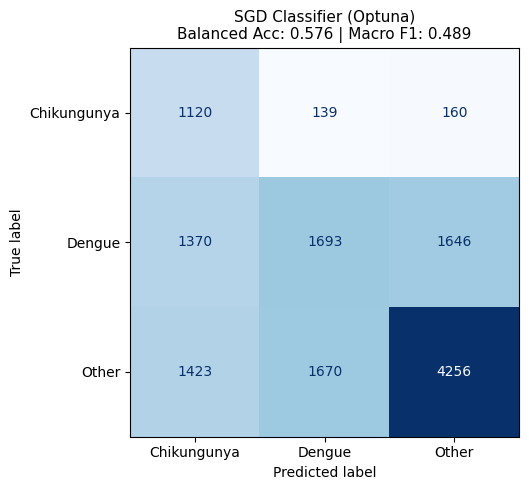

In [72]:
# --- Drop ALL rows that contain any missing value ---

# Stratified split on the clean subset
Xcc_sgdc = pd.concat([cc_train2, cc_test2], ignore_index=True).drop(columns=["target"])

Xcc_train_sgdc, Xcc_test_sgdc, ycc_train_sgdc, ycc_test_sgdc = cc_train2.drop(columns=["target"]), cc_test2.drop(columns=["target"]), cc_train2["target"], cc_test2["target"]
print(f'SGD Classifier Train: {Xcc_train_sgdc.shape}  |  SGD Classifier Test: {Xcc_test_sgdc.shape}')

sgdc_cat_cols = Xcc_sgdc.select_dtypes(include=['object', 'string']).columns.tolist()
sgdc_num_cols = Xcc_sgdc.select_dtypes(include=['number']).columns.tolist()

cc_sgdc_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), sgdc_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), sgdc_cat_cols)
])

ccsgdc_pipeline = Pipeline([
    ('preprocessor', cc_sgdc_preprocessor),
    ('classifier', SGDClassifier(
        max_iter=4000,
        random_state=RANDOM_STATE,
    ))
])

ccsgdc_param = {
    "classifier__loss": CategoricalDistribution(['hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive']),
    "classifier__penalty": CategoricalDistribution(['l2', 'l1', 'elasticnet']),
    "classifier__alpha": FloatDistribution(1e-5, 20, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__epsilon": FloatDistribution(1e-3, 1, log=True),
    "classifier__learning_rate": CategoricalDistribution(['constant', 'optimal', 'invscaling', 'adaptive']),
    "classifier__power_t": FloatDistribution(1e-2, 1.5, log=True),
    "classifier__eta0": FloatDistribution(1e-3, 2, log=True),
    "classifier__class_weight": CategoricalDistribution(['balanced', None]),
}

ccsgdc_search = OptunaSearchCV(
    estimator=ccsgdc_pipeline,
    param_distributions=ccsgdc_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

ccsgdc_search.fit(Xcc_train_sgdc, ycc_train_sgdc)

print("SGD Classifier best score:", ccsgdc_search.best_score_)
print("SGD Classifier best params:", ccsgdc_search.best_params_)

ccsgdc_best = ccsgdc_search.best_estimator_

ccres_sgdc = evaluate_model(
    "SGD Classifier (Optuna)",
    ccsgdc_best,
    Xcc_train_sgdc, ycc_train_sgdc,
    Xcc_test_sgdc, ycc_test_sgdc,
    le.classes_
)
results_cc.append(ccres_sgdc)

SGD Classifier best score: 0.5699018707998098
SGD Classifier best params: {'classifier__loss': 'log_loss', 'classifier__penalty': 'l2', 'classifier__alpha': 1.7602882315959455e-05, 'classifier__fit_intercept': False, 'classifier__tol': 0.0019681365802091716, 'classifier__epsilon': 0.0015046551015638688, 'classifier__learning_rate': 'adaptive', 'classifier__power_t': 0.3822288427552992, 'classifier__eta0': 0.009761115309346292, 'classifier__class_weight': None}

=======================================================
  SGD Classifier (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5760
  Macro F1          : 0.4891

              precision    recall  f1-score   support

 Chikungunya       0.29      0.79      0.42      1419
      Dengue       0.48      0.36      0.41      4709
       Other       0.70      0.58      0.63      7349

    accuracy                           0.52     13477
   macro avg       0.49      0.58      0.49     13477
weighted avg       0.58      0.52      0.53     13477
```

### PassiveAggressiveClassifier

[I 2026-05-30 13:46:59,085] A new study created in memory with name: no-name-e30a2672-38ed-4e76-83f8-5f036aff83d7


PassiveAggressive Train: (29576, 55) | PassiveAgressive Test: (7395, 55)


[W 2026-05-30 13:47:00,025] Trial 0 failed with parameters: {'classifier__C': 0.01971380348024695, 'classifier__fit_intercept': False, 'classifier__tol': 0.001507187697230704, 'classifier__early_stopping': True, 'classifier__loss': 'hinge', 'classifier__class_weight': None, 'classifier__average': 0} because of the following error: The value nan is not acceptable.
[W 2026-05-30 13:47:00,029] Trial 0 failed with value np.float64(nan).
[I 2026-05-30 13:47:01,535] Trial 1 finished with value: 0.5416059826605404 and parameters: {'classifier__C': 0.041151335369885675, 'classifier__fit_intercept': False, 'classifier__tol': 0.0012236121323342735, 'classifier__early_stopping': False, 'classifier__loss': 'hinge', 'classifier__class_weight': None, 'classifier__average': 24}. Best is trial 1 with value: 0.5416059826605404.
[I 2026-05-30 13:47:01,675] Trial 9 finished with value: 0.5446899431290685 and parameters: {'classifier__C': 0.7253488971655868, 'classifier__fit_intercept': False, 'classifier

PassiveAggressive best score: 0.5446899431290685
PassiveAggressive best params: {'classifier__C': 0.7253488971655868, 'classifier__fit_intercept': False, 'classifier__tol': 0.000772786527767408, 'classifier__early_stopping': False, 'classifier__loss': 'squared_hinge', 'classifier__class_weight': 'balanced', 'classifier__average': 4}

  PassiveAggressive Classifier (Optuna)
  Balanced Accuracy : 0.5658
  Macro F1          : 0.5519

              precision    recall  f1-score   support

 Chikungunya       0.45      0.60      0.51      1370
      Dengue       0.58      0.60      0.59      3147
       Other       0.62      0.50      0.55      2878

    accuracy                           0.56      7395
   macro avg       0.55      0.57      0.55      7395
weighted avg       0.57      0.56      0.56      7395



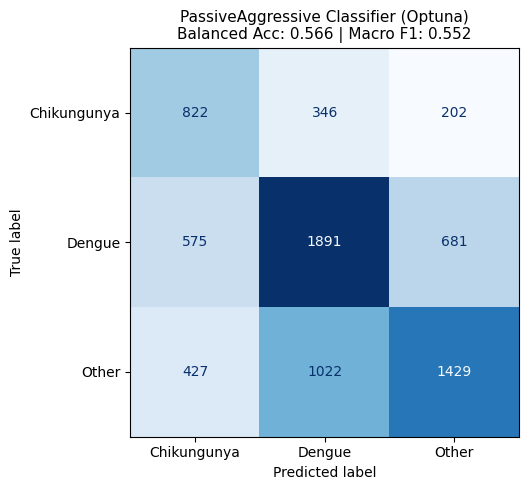

In [ ]:
recife_pac = recife.dropna()
X_pac = recife_pac.drop(columns=['target', 'target_with_severity'], errors='ignore')
y_pac = le.transform(recife_pac['target'])

X_train_pac, X_test_pac, y_train_pac, y_test_pac = train_test_split(
    X_pac, y_pac, test_size=0.2, random_state=RANDOM_STATE, stratify=y_pac
)
print(f"PassiveAggressive Train: {X_train_pac.shape} | PassiveAgressive Test: {X_test_pac.shape}")

pac_cat_cols = X_pac.select_dtypes(include=['object', 'string']).columns.tolist()
pac_num_cols = X_pac.select_dtypes(include=['number']).columns.tolist()

pac_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), pac_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), pac_cat_cols)
])

pac_pipeline = Pipeline([
    ('preproccesor', pac_preprocessor),
    ('classifier', PassiveAggressiveClassifier(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ))
])

pac_params = {
    "classifier__C": FloatDistribution(1e-3, 20, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__early_stopping": CategoricalDistribution([False, True]),
    "classifier__loss": CategoricalDistribution(["hinge", "squared_hinge"]),
    "classifier__class_weight": CategoricalDistribution(["balanced", None]),
    "classifier__average": IntDistribution(0, 40, step=4),
}

pac_search = OptunaSearchCV(
    estimator=pac_pipeline,
    param_distributions=pac_params,
    cv=cv,
    scoring="f1_macro",
    n_trials=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

pac_search.fit(X_train_pac, y_train_pac)

print("PassiveAggressive best score:", pac_search.best_score_)
print("PassiveAggressive best params:", pac_search.best_params_)

pac_best = pac_search.best_estimator_
res_pac = evaluate_model(
    "PassiveAggressive Classifier (Optuna)",
    pac_best,
    X_train_pac, y_train_pac,
    X_test_pac, y_test_pac,
    le.classes_
)
results.append(res_pac)

PassiveAggressive best score: 0.5446899431290685

PassiveAggressive best params: {'classifier__C': 0.7253488971655868, 'classifier__fit_intercept': False, 'classifier__tol': 0.000772786527767408, 'classifier__early_stopping': False, 'classifier__loss': 'squared_hinge', 'classifier__class_weight': 'balanced', 'classifier__average': 4}

=======================================================
  PassiveAggressive Classifier (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5658
  Macro F1          : 0.5519

              precision    recall  f1-score   support

 Chikungunya       0.45      0.60      0.51      1370
      Dengue       0.58      0.60      0.59      3147
       Other       0.62      0.50      0.55      2878

    accuracy                           0.56      7395
   macro avg       0.55      0.57      0.55      7395
weighted avg       0.57      0.56      0.56      7395
```

### Perceptron

[I 2026-05-30 13:48:42,101] A new study created in memory with name: no-name-a9ab553a-669d-4ea6-89b9-c941d0a00567


Perceptron Train: (29576, 55) | Perceptron Test: (7395, 55)


[I 2026-05-30 13:48:45,765] Trial 3 finished with value: 0.37255019476575024 and parameters: {'classifier__penalty': 'l2', 'classifier__alpha': 0.0035662261679139306, 'classifier__fit_intercept': False, 'classifier__tol': 0.000854213470066129, 'classifier__eta0': 0.4316113752042083, 'classifier__class_weight': 'balanced'}. Best is trial 3 with value: 0.37255019476575024.
[I 2026-05-30 13:48:45,850] Trial 10 finished with value: 0.39896731865152285 and parameters: {'classifier__penalty': 'l2', 'classifier__alpha': 0.000778664965303381, 'classifier__fit_intercept': False, 'classifier__tol': 0.0068564965507363984, 'classifier__eta0': 0.04982122676492337, 'classifier__class_weight': 'balanced'}. Best is trial 10 with value: 0.39896731865152285.
[I 2026-05-30 13:48:46,020] Trial 6 finished with value: 0.4312020758470835 and parameters: {'classifier__penalty': 'l2', 'classifier__alpha': 0.00018044293230001126, 'classifier__fit_intercept': True, 'classifier__tol': 0.008160895574573524, 'class

Perceptron best score: 0.4560555608901181
Perceptron best params: {'classifier__penalty': 'l1', 'classifier__alpha': 4.213834232540949e-05, 'classifier__fit_intercept': True, 'classifier__tol': 0.008545218901583995, 'classifier__eta0': 0.5058504510146523, 'classifier__class_weight': 'balanced'}

  Perceptron (Optuna)
  Balanced Accuracy : 0.3860
  Macro F1          : 0.3269

              precision    recall  f1-score   support

 Chikungunya       0.31      0.04      0.07      1370
      Dengue       0.46      0.92      0.62      3147
       Other       0.61      0.19      0.29      2878

    accuracy                           0.48      7395
   macro avg       0.46      0.39      0.33      7395
weighted avg       0.49      0.48      0.39      7395



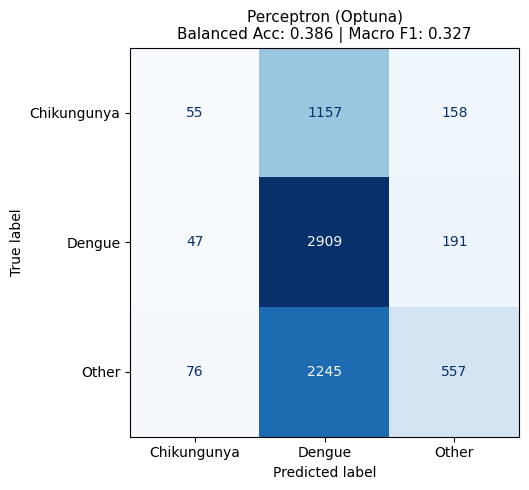

In [ ]:
recife_pct = recife.dropna()
X_pct = recife_pct.drop(columns=['target', 'target_with_severity'], errors='ignore')
y_pct = le.transform(recife_pct['target'])

X_train_pct, X_test_pct, y_train_pct, y_test_pct = train_test_split(
    X_pct, y_pct, test_size=0.2, random_state=RANDOM_STATE, stratify=y_pct
)
print(f"Perceptron Train: {X_train_pct.shape} | Perceptron Test: {X_test_pct.shape}")

pct_cat_cols = X_pct.select_dtypes(include=['object', 'string']).columns.tolist()
pct_num_cols = X_pct.select_dtypes(include=['number']).columns.tolist()

pct_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), pct_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), pct_cat_cols)
])

pct_pipeline = Pipeline([
    ('preproccesor', pct_preprocessor),
    ('classifier', Perceptron(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ))
])

pct_params = {
    "classifier__penalty": CategoricalDistribution(['l2', 'l1', 'elasticnet', None]),
    "classifier__alpha": FloatDistribution(1e-5, 1e-2, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__eta0": FloatDistribution(1e-2, 1.5, log=True),
    "classifier__class_weight": CategoricalDistribution(["balanced", None]),
}

pct_search = OptunaSearchCV(
    estimator=pct_pipeline,
    param_distributions=pct_params,
    cv=cv,
    scoring="f1_macro",
    n_trials=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

pct_search.fit(X_train_pct, y_train_pct)

print("Perceptron best score:", pct_search.best_score_)
print("Perceptron best params:", pct_search.best_params_)

pct_best = pct_search.best_estimator_
res_pct = evaluate_model(
    "Perceptron (Optuna)",
    pct_best,
    X_train_pct, y_train_pct,
    X_test_pct, y_test_pct,
    le.classes_
)
results.append(res_pct)

## 7. Model 4 — HistGradientBoosting
Natively supports missing values. Class weights applied via `class_weight`.

[I 2026-05-30 13:53:21,255] A new study created in memory with name: no-name-6d471145-2113-49bb-8543-6da86d80d5fb
[I 2026-05-30 13:54:57,155] Trial 1 finished with value: 0.6038034297414392 and parameters: {'classifier__learning_rate': 0.0905082409073877, 'classifier__max_iter': 440, 'classifier__max_depth': 12, 'classifier__max_leaf_nodes': 49, 'classifier__min_samples_leaf': 34, 'classifier__l2_regularization': 0.5621660527598668, 'classifier__max_bins': 222}. Best is trial 1 with value: 0.6038034297414392.
[I 2026-05-30 13:55:04,696] Trial 7 finished with value: 0.6026836576127665 and parameters: {'classifier__learning_rate': 0.061653353608233714, 'classifier__max_iter': 580, 'classifier__max_depth': 18, 'classifier__max_leaf_nodes': 31, 'classifier__min_samples_leaf': 19, 'classifier__l2_regularization': 0.05879249978506015, 'classifier__max_bins': 232}. Best is trial 1 with value: 0.6038034297414392.
[I 2026-05-30 13:55:21,991] Trial 3 finished with value: 0.6060150671336084 and p

HGB best score: 0.6060150671336084
HGB best params: {'classifier__learning_rate': 0.08025861717554916, 'classifier__max_iter': 600, 'classifier__max_depth': 17, 'classifier__max_leaf_nodes': 50, 'classifier__min_samples_leaf': 34, 'classifier__l2_regularization': 0.003482251406470383, 'classifier__max_bins': 224}

  HistGradientBoosting (Optuna)
  Balanced Accuracy : 0.5957
  Macro F1          : 0.5976

              precision    recall  f1-score   support

 Chikungunya       0.54      0.52      0.53      1369
      Dengue       0.62      0.70      0.66      3148
       Other       0.65      0.57      0.61      2883

    accuracy                           0.62      7400
   macro avg       0.60      0.60      0.60      7400
weighted avg       0.62      0.62      0.61      7400



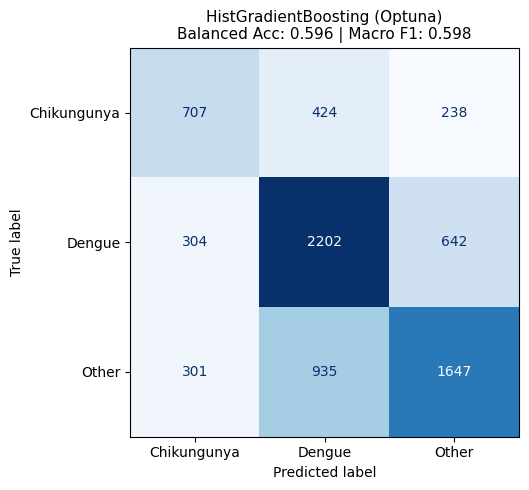

In [ ]:
# HistGradientBoosting handles NaN natively for numerics,
# but categoricals still need encoding
from sklearn.preprocessing import OrdinalEncoder as OE
X_train_hgb, X_test_hgb = X_train.copy(), X_test.copy()

hgb_cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OE(handle_unknown='use_encoded_value', unknown_value=-1))
])

hgb_preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),  # no scaling needed for HGB
    ('cat', hgb_cat_transformer, cat_cols)
])

# Compute class weights manually
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
hgb_w = np.array([cw[c] for c in y_train])

hgb_model = Pipeline([
    ('preprocessor', hgb_preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        early_stopping=True,
        class_weight=None,
    ))
])

hgb_param_distributions = {
    'classifier__learning_rate': FloatDistribution(1e-2, 0.1, log=True),
    'classifier__max_iter': IntDistribution(400, 800, step=20),
    'classifier__max_depth': IntDistribution(10, 18),
    'classifier__max_leaf_nodes': IntDistribution(30, 63),
    'classifier__min_samples_leaf': IntDistribution(16, 40, step=3),
    'classifier__l2_regularization': FloatDistribution(1e-6, 10.0, log=True),
    'classifier__max_bins': IntDistribution(180, 255),
}
{'classifier__learning_rate': 0.041781191122534866, 'classifier__max_iter': 650, 'classifier__max_depth': 15, 'classifier__max_leaf_nodes': 48,
 'classifier__min_samples_leaf': 25, 'classifier__l2_regularization': 0.04868692584193857, 'classifier__max_bins': 251}
hgb_search = OptunaSearchCV(
    estimator=hgb_model,
    param_distributions=hgb_param_distributions,
    cv=cv,
    scoring=f1_macro,
    n_trials=25,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

hgb_search.fit(X_train_hgb, y_train)

print("HGB best score:", hgb_search.best_score_)
print("HGB best params:", hgb_search.best_params_)

hgb_best = hgb_search.best_estimator_

res = evaluate_model(
    'HistGradientBoosting (Optuna)',
    hgb_best,
    X_train_hgb, y_train,
    X_test_hgb, y_test,
    le.classes_
)
results.append(res)

HGB best score: 0.6060150671336084

HGB best params: {'classifier__learning_rate': 0.08025861717554916, 'classifier__max_iter': 600, 'classifier__max_depth': 17, 'classifier__max_leaf_nodes': 50, 'classifier__min_samples_leaf': 34, 'classifier__l2_regularization': 0.003482251406470383, 'classifier__max_bins': 224}

=======================================================
  HistGradientBoosting (Optuna)
=======================================================
```
  Balanced Accuracy : 0.5957
  Macro F1          : 0.5976

              precision    recall  f1-score   support

 Chikungunya       0.54      0.52      0.53      1369
      Dengue       0.62      0.70      0.66      3148
       Other       0.65      0.57      0.61      2883

    accuracy                           0.62      7400
   macro avg       0.60      0.60      0.60      7400
weighted avg       0.62      0.62      0.61      7400

```

# 8. Model 5 - KNN

[I 2026-05-30 14:06:35,514] A new study created in memory with name: no-name-c1716f41-4d05-4bae-b2e3-076ba6188f89


[I 2026-05-30 14:06:40,361] Trial 0 finished with value: 0.5564439678821756 and parameters: {'classifier__n_neighbors': 17, 'classifier__weights': 'uniform', 'classifier__p': 1, 'classifier__algorithm': 'auto', 'classifier__leaf_size': 21, 'classifier__n_jobs': -1}. Best is trial 0 with value: 0.5564439678821756.
[I 2026-05-30 14:06:51,202] Trial 1 finished with value: 0.5596590077196689 and parameters: {'classifier__n_neighbors': 31, 'classifier__weights': 'uniform', 'classifier__p': 1, 'classifier__algorithm': 'kd_tree', 'classifier__leaf_size': 30, 'classifier__n_jobs': -1}. Best is trial 1 with value: 0.5596590077196689.
[I 2026-05-30 14:06:53,028] Trial 2 finished with value: 0.5485489717608943 and parameters: {'classifier__n_neighbors': 29, 'classifier__weights': 'distance', 'classifier__p': 2, 'classifier__algorithm': 'auto', 'classifier__leaf_size': 25, 'classifier__n_jobs': None}. Best is trial 1 with value: 0.5596590077196689.
[I 2026-05-30 14:06:54,582] Trial 3 finished with

KNN best score: 0.5597800823000606
KNN best params: {'classifier__n_neighbors': 31, 'classifier__weights': 'uniform', 'classifier__p': 1, 'classifier__algorithm': 'brute', 'classifier__leaf_size': 25, 'classifier__n_jobs': -1}

  KNN (Optuna)
  Balanced Accuracy : 0.5546
  Macro F1          : 0.5603

              precision    recall  f1-score   support

 Chikungunya       0.53      0.43      0.48      1369
      Dengue       0.57      0.72      0.64      3148
       Other       0.63      0.51      0.56      2883

    accuracy                           0.59      7400
   macro avg       0.58      0.55      0.56      7400
weighted avg       0.59      0.59      0.58      7400



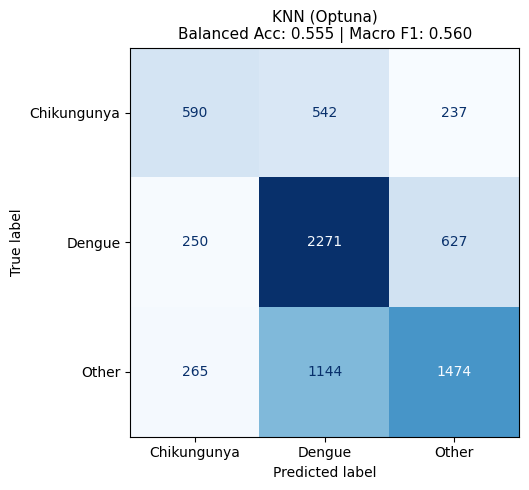

In [21]:
# numeric -> median impute + scale, categorical -> mode impute + ordinal encode.
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(
        metric='minkowski'
    ))
])

knn_param = {
    'classifier__n_neighbors': IntDistribution(7, 31, step=2),
    'classifier__weights': CategoricalDistribution(['uniform', 'distance']),
    'classifier__p': IntDistribution(1, 2),
    'classifier__algorithm': CategoricalDistribution(['auto', 'ball_tree', 'kd_tree', 'brute']),
    'classifier__leaf_size': IntDistribution(20, 30),
    'classifier__n_jobs': CategoricalDistribution([None, -1])  # use all cores for KNN
}

knn_search = OptunaSearchCV(
    estimator=knn_pipeline,
    param_distributions=knn_param,
    cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE),
    scoring=f1_macro,
    n_trials=20,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    refit=True
)

knn_search.fit(X_train, y_train)

print('KNN best score:', knn_search.best_score_)
print('KNN best params:', knn_search.best_params_)

knn_best = knn_search.best_estimator_

res = evaluate_model(
    'KNN (Optuna)',
    knn_best,
    X_train, y_train,
    X_test, y_test,
    le.classes_
)
results.append(res)

## 8. Model Comparison

                                       balanced_acc  macro_f1
model                                                        
Random Forest (Optuna)                     0.622003  0.602608
HistGradientBoosting (Optuna)              0.595736  0.597573
CatBoost (Optuna)                          0.614496  0.595359
KNN (Optuna)                               0.554552  0.560290
PassiveAggressive Classifier (Optuna)      0.565805  0.551924
Logistic Regression (Optuna)               0.539656  0.543117
SGD Classifier (Optuna)                    0.526786  0.533279
Ridge Classifier (Optuna)                  0.523849  0.529938
Ridge Classifier (Optuna)                  0.522991  0.529068
Perceptron (Optuna)                        0.386019  0.326866


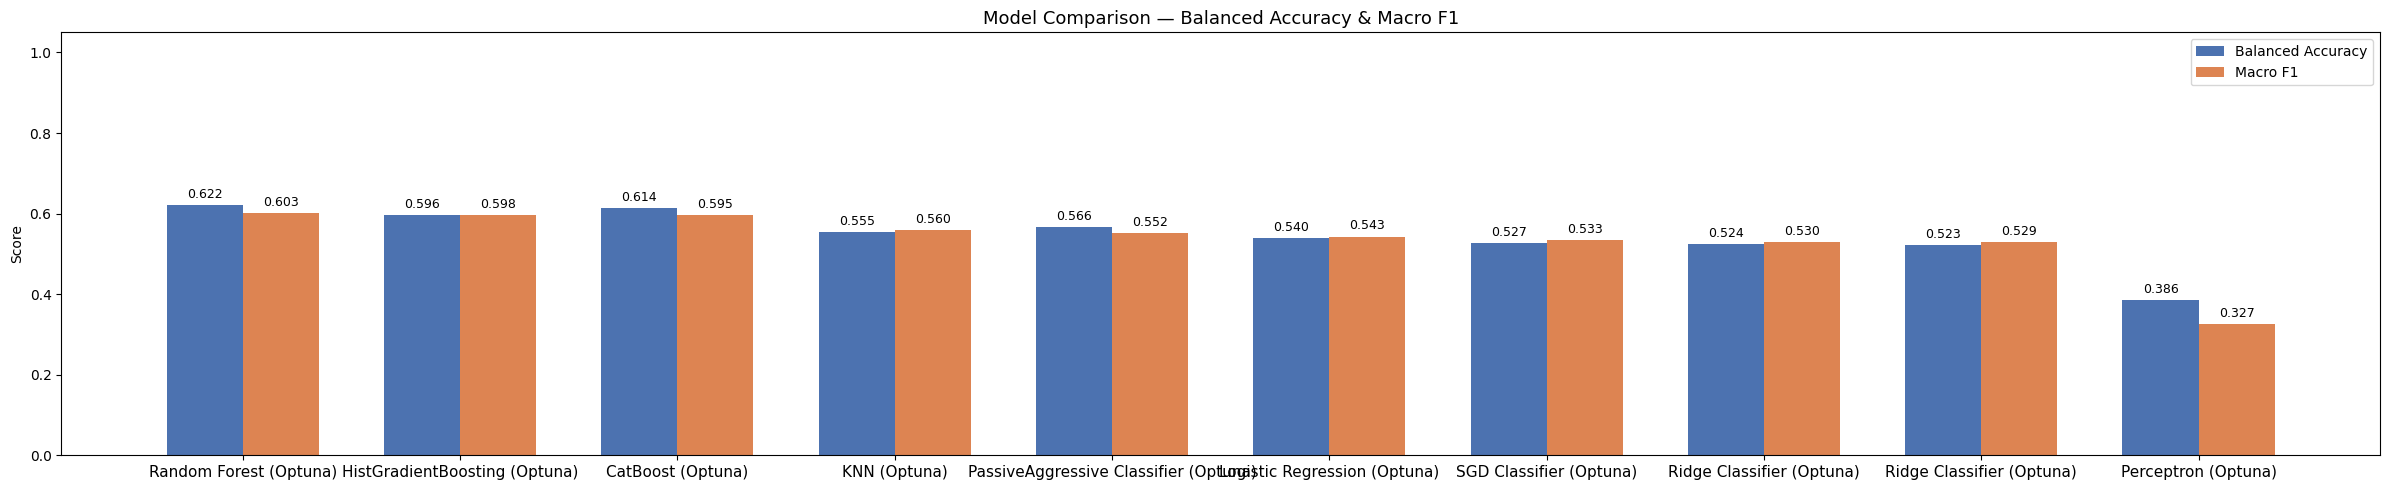


🏆 Best model by Macro F1: Random Forest (Optuna)


In [ ]:
results_recife = pd.DataFrame(results).sort_values('macro_f1', ascending=False)
results_recife = results_recife.set_index('model')
print(results_recife.to_string())

fig, ax = plt.subplots(figsize=(27, 5))
x = np.arange(len(results_recife))
width = 0.35

bars1 = ax.bar(x - width/2, results_recife['balanced_acc'], width,
               label='Balanced Accuracy', color='#4C72B0')
bars2 = ax.bar(x + width/2, results_recife['macro_f1'], width,
               label='Macro F1', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(results_recife.index, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Balanced Accuracy & Macro F1', fontsize=13)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best = results_recife['macro_f1'].idxmax()
print(f'\n🏆 Best model by Macro F1: {best}')

## 9. Feature Importance (CatBoost & Random Forest)

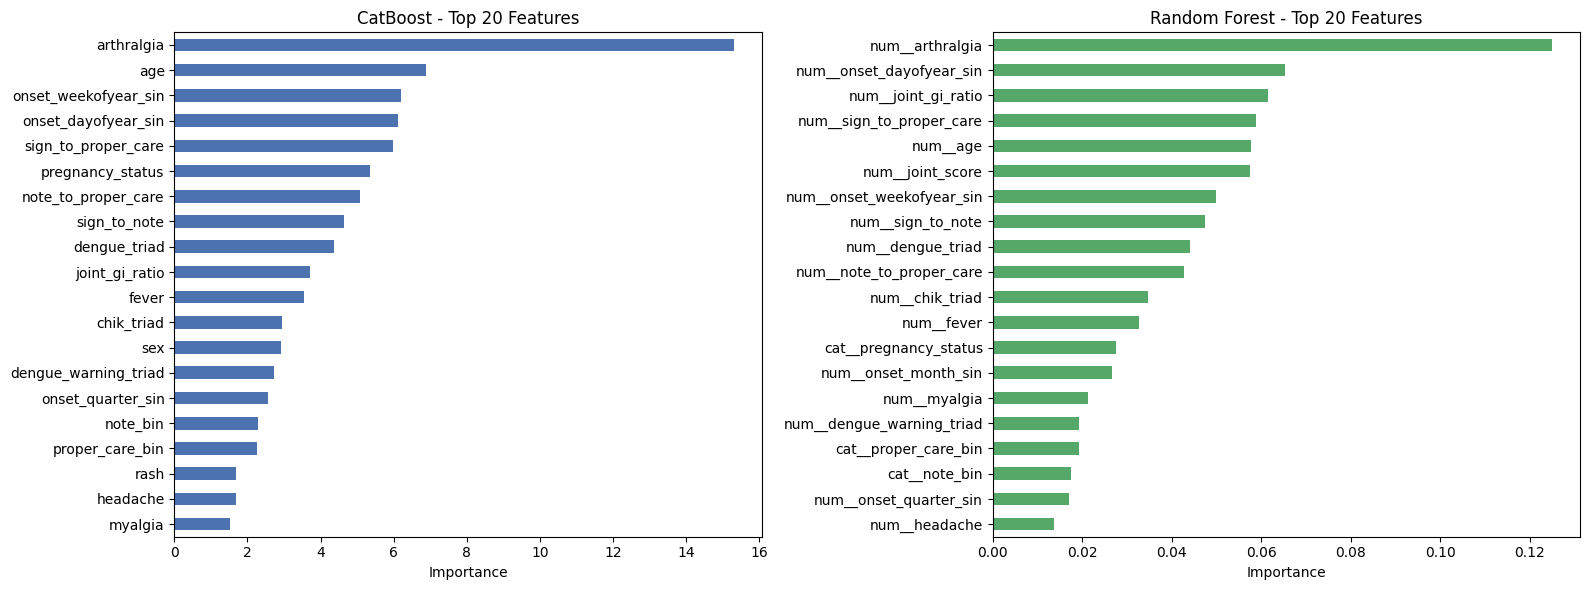

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CatBoost feature importance
if 'catboost_best' in globals():
    cb_fi = pd.Series(
        catboost_best.get_feature_importance(),
        index=X_train_cb.columns
    ).sort_values(ascending=False).head(20)

    cb_fi.plot(kind='barh', ax=axes[0], color='#4C72B0')
    axes[0].invert_yaxis()
    axes[0].set_title('CatBoost - Top 20 Features', fontsize=12)
    axes[0].set_xlabel('Importance')
else:
    axes[0].text(0.5, 0.5, 'Run CatBoost first', ha='center', va='center')
    axes[0].set_axis_off()

# Random Forest feature importance
if 'rf_best' in globals():
    rf_feature_names = rf_best.named_steps['preprocessor'].get_feature_names_out()
    rf_fi = pd.Series(
        rf_best.named_steps['classifier'].feature_importances_,
        index=rf_feature_names
    ).sort_values(ascending=False).head(20)

    rf_fi.plot(kind='barh', ax=axes[1], color='#55A868')
    axes[1].invert_yaxis()
    axes[1].set_title('Random Forest - Top 20 Features', fontsize=12)
    axes[1].set_xlabel('Importance')
else:
    axes[1].text(0.5, 0.5, 'Run Random Forest first', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


## Conclusions
### 1. This is not simply a linear-problem (or at least the overall dataset).
Using Tree-based algorithm would suit better.
Unless we can divide the dataset into a linear subcategory, a multi-polynomial or conditional subcategory, using **XGBoost**, **HistGradientBoosting** and **CatBoost** would be the best.

### 2. race priority problem?
Since we are Yellow-skinned, race really affects the prediction for Vietnamese people. Really consider dropping it.

### 3. 